# Regressão Logística 

### 0.0 Utils

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """ Função sigmoid: converte valores em probabilidades entre 0 e 1 """
    return 1 / (1 + np.exp(-z))

def compute_cost(x, y, weights):
    """ Calcula a função de custo (log loss) para regressão logística"""
    m = len(y)
    h = sigmoid(np.dot(x, weights))
    
    # Evita log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

def compute_gradient(x, y, weights):
    """ Calcula o gradiente da função de custo """
    m = len(y)
    h = sigmoid(np.dot(x, weights))
    gradient = (1/m) * np.dot(x.T, (h - y))
    return gradient

def gradient_descent(x, y, learning_rate=0.01, iterations=1000, verbose=True):
    """ Implementa o algoritmo de gradient descent para otimizar os pesos """
    weights = np.zeros(x.shape[1])
    cost_history = []
    
    for i in range(iterations):
        gradient = compute_gradient(x, y, weights)
        weights = weights - learning_rate * gradient
        
        cost = compute_cost(x, y, weights)
        cost_history.append(cost)
        
        if verbose and (i % 100 == 0):
            print(f"Iteração {i}: Custo = {cost:.4f}")
    
    return weights, cost_history

def predict_probability(x, weights):
    """ Retorna as probabilidades preditas"""
    return sigmoid(np.dot(x, weights))

def predict(x, weights, threshold=0.5):
    """ Retorna as classes preditas (0 ou 1)"""
    probabilities = predict_probability(x, weights)
    return (probabilities >= threshold).astype(int)

### 1. Preparação dos dados

In [7]:
# Exploração inicial dos dados de câncer de mama
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data['feature_names'])
df['target'] = data.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [8]:
x = df.drop('target', axis=1).values # features 
y = df['target'].values # target

In [9]:
np.random.seed(42)
indices = np.arange(x.shape[0])
np.random.shuffle(indices)

test_size_n = int(x.shape[0] * 0.2)
test_indices = indices[:test_size_n]
train_indices = indices[test_size_n:]

X_train = x[train_indices]
X_test = x[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
    
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)

X_train_normalized = (X_train - X_train_mean) / X_train_std
X_test_normalized = (X_test - X_train_mean) / X_train_std

if np.std(X_train_normalized, axis=0).any() != 1.0 or np.mean(X_test_normalized, axis=0).any() != 1.0:
    raise ValueError("Erro na normalização!")

# Adicionar o termo de bias (intercepto) para facilitar os cálculos matriciais
X_train = np.c_[np.ones(X_train_normalized.shape[0]), X_train_normalized]
X_test = np.c_[np.ones(X_test_normalized.shape[0]), X_test_normalized]

### 2. Treinamento

In [ ]:
print("Treinando o modelo...")
weights, cost_history = gradient_descent(X_train, y_train, learning_rate=0.1, iterations=1000)
print(f"\nCusto final: {cost_history[-1]:.4f}")

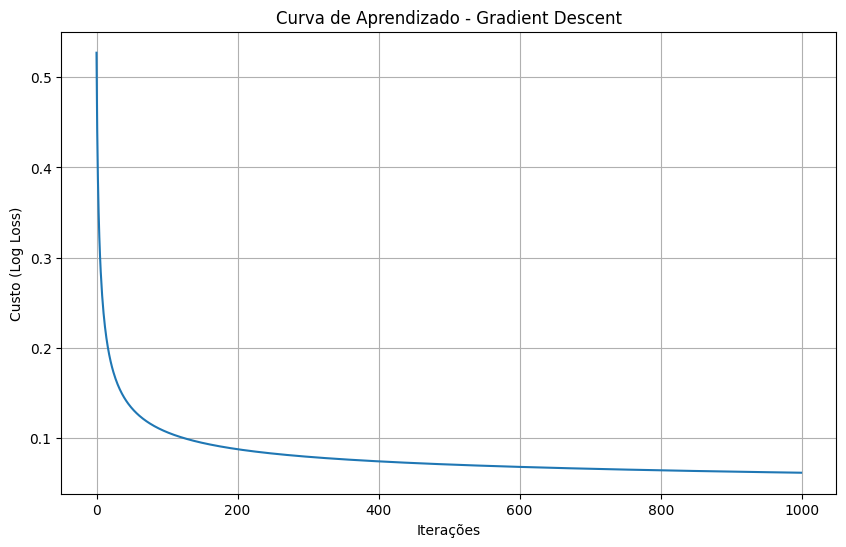

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.xlabel('Iterações')
plt.ylabel('Custo (Log Loss)')
plt.title('Curva de Aprendizado - Gradient Descent')
plt.grid(True)
plt.show()

In [13]:
y_train_pred = predict(X_train, weights)
y_test_pred = predict(X_test, weights)

print(f"Predições no treino: {y_train_pred[:10]}")
print(f"Valores reais: {y_train[:10]}")

Predições no treino: [0 1 0 1 1 1 0 1 1 1]
Valores reais: [0 1 0 1 1 1 0 1 1 1]


### 3. Avaliação

In [14]:
from sklearn.metrics import classification_report

print("=" * 60)
print("AVALIAÇÃO NO CONJUNTO DE TREINO")
print("=" * 60)
print(classification_report(y_train, y_train_pred, digits=4))

print("\n" + "=" * 60)
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print("=" * 60)
print(classification_report(y_test, y_test_pred, digits=4))

AVALIAÇÃO NO CONJUNTO DE TREINO
              precision    recall  f1-score   support

           0     0.9881    0.9765    0.9822       170
           1     0.9861    0.9930    0.9895       286

    accuracy                         0.9868       456
   macro avg     0.9871    0.9847    0.9859       456
weighted avg     0.9869    0.9868    0.9868       456


AVALIAÇÃO NO CONJUNTO DE TESTE
              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9859    0.9859    0.9859        71

    accuracy                         0.9823       113
   macro avg     0.9811    0.9811    0.9811       113
weighted avg     0.9823    0.9823    0.9823       113



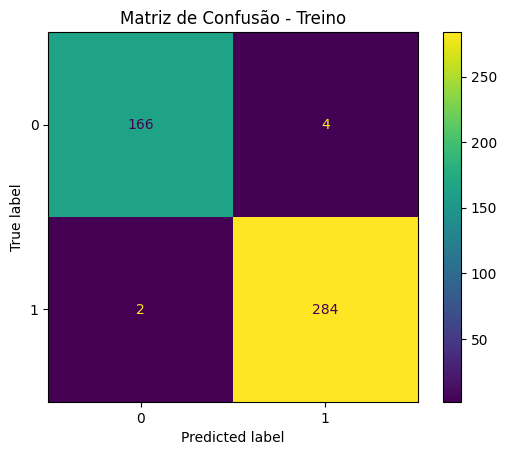

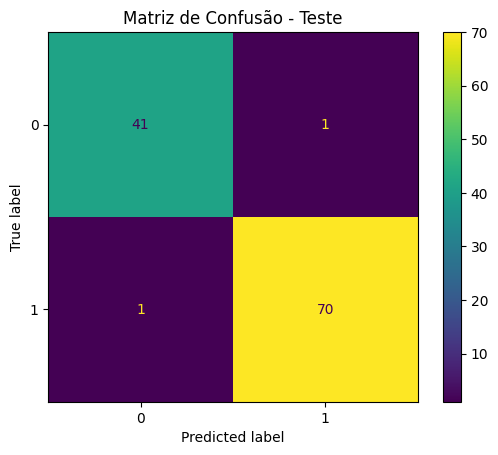

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.title("Matriz de Confusão - Treino")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title("Matriz de Confusão - Teste")
plt.show()